## Import libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor

Storing the data in a dataframe

In [73]:
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')

In [74]:
print(df["date"].min(), "to", df["date"].max())
df.head()

1992-01-05 00:00:00 to 2024-10-26 00:00:00


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,2024-10-26,219,0,Villa,regular_sale,1974,4350000,0.0,5,215.0,20232.558594,Kildevangen 5,8382,Hinnerup,East & mid jutland,Jutland,3.1,NaN,NaN
1,2024-10-26,219,2,Summerhouse,regular_sale,1956,450000,0.0,3,36.0,12500.000000,Lykkestien 2,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
2,2024-10-26,219,1,Farm,regular_sale,1955,6600000,0.0,3,180.0,36666.667969,Sæderupvej 58,9260,Gistrup,North jutland,Jutland,3.1,NaN,NaN
3,2024-10-25,219,3,Apartment,family_sale,1945,1495000,0.0,2,64.0,23359.375000,"Tage-Hansens Gade 5, 1. tv",8000,Aarhus C,East & mid jutland,Jutland,3.1,NaN,NaN
4,2024-10-25,219,4,Villa,regular_sale,1967,3375000,0.0,5,176.0,19176.136719,Chr.Winthers Vej 5,8600,Silkeborg,East & mid jutland,Jutland,3.1,NaN,NaN


In [75]:
#Drop all rows with na in the sqm column
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


#### Quarter skal laves til en float istedet for datetime

In [76]:
#Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")
df.head()


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


### Make dummy variables

In [77]:
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "nom_interest_rate%" ]])
y = df["purchase_price"]
X.shape, y.shape
X.head()

,quarter,year_build,no_rooms,sqm,zip_code,nom_interest_rate%,house_type_Apartment,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,house_type_Villa,sales_type_-,sales_type_auction,sales_type_family_sale,sales_type_other_sale,sales_type_regular_sale
1193,218,1971,3,78.0,2640,3.35,True,False,False,False,False,False,False,False,False,True
1194,218,2009,3,50.0,2635,3.35,False,False,True,False,False,False,False,False,False,True
1195,218,1940,2,56.0,2800,3.35,True,False,False,False,False,False,False,False,False,True
1196,218,1950,4,72.0,3730,3.35,False,False,True,False,False,False,False,True,False,False
1197,218,1974,1,50.0,2200,3.35,True,False,False,False,False,False,False,False,False,True


Make the training and testing split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [79]:
# Create and fit the model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
#Evaluate the model
print("Score on training set: {:.3f}".format(simple_model.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(simple_model.score(X_test, y_test)))

Score on training set: 0.290
Score on test set: 0.290


## Polynomial Regression
Now we will try to improve the model by making it polynomial.

In [81]:
# take a random 50% sample (deterministic via random_state) to reduce memory use
df = df.sample(frac=0.05, random_state=42).copy()
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "nom_interest_rate%" ]])
y = df["purchase_price"]
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,house_type_Apartment,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,house_type_Villa,...,sales_type_other_sale,sales_type_regular_sale,area_Bornholm,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
465021,199,1974,5,129.0,0.00,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
742767,181,1968,6,148.0,0.00,False,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
1167754,139,2006,3,128.0,2.00,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1051169,149,2003,5,149.0,3.75,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
412051,201,1968,4,86.0,0.00,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False


In [82]:
# make train-test split to get X_train, X_test, y_train, and y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

We use the code below to create polynomial features on the training data to the degree of 5. 

In [83]:
# Let's try with degree 2 instead of 3 to reduce memory usage
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Only transform, don't fit again

In [84]:
# Create and fit the model
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Evaluating the model

In [85]:
print("Score on training set: {:.3f}".format(poly_lr.score(X_train_poly, y_train)))
print("Score on test set: {:.3f}".format(poly_lr.score(X_test_poly, y_test)))

Score on training set: 0.466
Score on test set: 0.440


## K-nearest neighbor

In [86]:
# take a random 50% sample (deterministic via random_state) to reduce memory use
df = df.sample(frac=0.05, random_state=42).copy()
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "nom_interest_rate%" ]])
y = df["purchase_price"]
X.shape, y.shape
X.head()

,quarter,year_build,no_rooms,sqm,zip_code,nom_interest_rate%,house_type_Apartment,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,house_type_Villa,sales_type_-,sales_type_auction,sales_type_family_sale,sales_type_other_sale,sales_type_regular_sale
294442,205,1950,5,143.0,9200,0.0,False,False,False,False,True,False,False,False,False,True
674694,186,2001,5,146.0,4000,0.0,False,False,False,False,True,False,False,False,False,True
1459084,98,1967,5,133.0,2650,5.0,False,False,False,False,True,False,False,False,False,True
601480,192,1967,5,150.0,9700,0.0,False,False,False,False,True,False,False,False,False,True
1194658,136,1917,3,163.0,6650,2.0,False,True,False,False,False,False,False,True,False,False


In [87]:
print(df["date"].min(), "to", df["date"].max())
df.head()

1992-01-06 00:00:00 to 2024-09-30 00:00:00


,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
294442,2021-05-16,205,283517,Villa,regular_sale,1950,4345000,-1.0,5,143.0,30384.615234,Johannes V. Jensens Vej 3,9200,Aalborg SV,North jutland,Jutland,0.0,1.85,1.47
674694,2016-07-12,186,665989,Villa,regular_sale,2001,4450000,1.0,5,146.0,30479.451172,Linkøpingvej 235,4000,Roskilde,Other islands,Zealand,0.0,0.25,2.55
1459084,1994-08-20,98,1457046,Villa,regular_sale,1967,1043382,0.0,5,133.0,7844.977539,Frydenstrands Alle 48,2650,Hvidovre,"Capital, Copenhagen",Zealand,5.0,1.99,8.39
601480,2018-03-09,192,592642,Villa,regular_sale,1967,940000,-6.0,5,150.0,6266.666504,Søndergade 75,9700,Brønderslev,North jutland,Jutland,0.0,0.81,2.12
1194658,2004-03-02,136,1190302,Farm,family_sale,1917,3094073,0.0,3,163.0,18982.042969,Nørre Vittrupvej 8,6650,Brørup,South jutland,Jutland,2.0,1.15,5.26


Changing zip_code from int to object.

In [88]:
df['zip_code'] = df['zip_code'].astype('object')

Inspecting variable types assigned to each column.

In [89]:
df.dtypes

date                                   datetime64[ns]
quarter                                         int64
house_id                                        int64
house_type                                   category
sales_type                                   category
year_build                                      int16
purchase_price                                  int32
%_change_between_offer_and_purchase           float32
no_rooms                                         int8
sqm                                           float32
sqm_price                                     float32
address                                        object
zip_code                                       object
city                                           object
area                                         category
region                                       category
nom_interest_rate%                            float32
dk_ann_infl_rate%                             float32
yield_on_mortgage_credit_bon

Generating descriptive statistics for the continuous variables in the dataset.

In [90]:
df.describe()

,date,quarter,house_id,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
count,3767,3767.000000,3.767000e+03,3767.000000,3.767000e+03,3767.000000,3767.000000,3767.000000,3767.000000,3767.000000,3767.000000,3767.000000
mean,2012-10-21 00:00:00,170.714892,7.529560e+05,1955.029466,1.904577e+06,-2.144146,4.322538,128.334488,16327.499023,1.638917,1.942384,4.091155
min,1992-01-06 00:00:00,88.000000,1.332000e+03,1000.000000,2.503360e+05,-46.000000,1.000000,26.000000,576.387146,0.000000,0.250000,1.100000
25%,2005-08-22 00:00:00,142.000000,3.784085e+05,1931.000000,8.132425e+05,-3.000000,3.000000,87.000000,7087.236572,0.000000,0.790000,2.120000
50%,2015-03-22 00:00:00,180.000000,7.494140e+05,1966.000000,1.395000e+06,0.000000,4.000000,123.000000,12121.211914,0.750000,1.850000,3.730000
75%,2020-09-19 12:00:00,202.000000,1.131268e+06,1980.000000,2.399000e+06,0.000000,5.000000,159.000000,21318.814453,3.250000,2.340000,5.500000
max,2024-09-30 00:00:00,218.000000,1.506113e+06,2024.000000,1.945000e+07,34.000000,15.000000,917.000000,74299.062500,9.500000,7.700000,10.140000
std,NaN,36.059665,4.328507e+05,46.929110,1.740691e+06,4.778657,1.626186,57.849419,13410.492188,2.024437,1.671330,2.193420


Making a train-test split.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

Using StandardScaler to standardize the scales of attributes.

In [92]:
scaler = StandardScaler() # define the scaler
X_train_scaled = scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_scaled = scaler.transform(X_test) # apply to the testing feature matrix

Applying RobustScaler.

In [93]:
robust_scaler = RobustScaler() # define the scaler
X_train_robust = robust_scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_robust = robust_scaler.transform(X_test) # apply to the testing feature matrix

Fitting a KNeighborsRegrssor and defining it as knn.

In [94]:
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [95]:
# print scores
print("Score on training set: {:.3f}".format(knn.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(knn.score(X_test, y_test)))

Score on training set: 0.521
Score on test set: 0.312


Fitting a KNeighborsRegressor and defining it as knn_scaled.

In [96]:
knn_scaled = KNeighborsRegressor()
knn_scaled.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [97]:
# print scores
print("Score on training set: {:.3f}".format(knn_scaled.score(X_train_scaled, y_train)))
print("Score on test set: {:.3f}".format(knn_scaled.score(X_test_scaled, y_test)))

Score on training set: 0.530
Score on test set: 0.316


Fitting a KNeighborsRegrssor and defining it as knn_robust.

In [98]:
knn_robust = KNeighborsRegressor()
knn_robust.fit(X_train_robust, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [99]:
# print scores
print("Score on training set: {:.3f}".format(knn_robust.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(knn_robust.score(X_test_robust, y_test)))

Score on training set: 0.538
Score on test set: 0.301


Creating a boxplot.

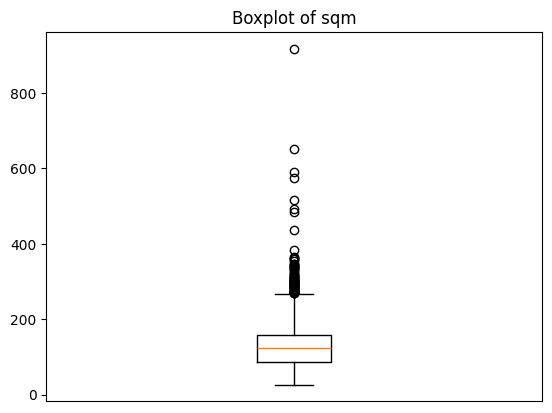

In [100]:
plt.boxplot(df['sqm'])
plt.title('Boxplot of sqm')
plt.xticks([])  
plt.show()

Setting up a parameter grid.

In [101]:
param_grid = {
    'n_neighbors': [1, 5, 10, 20, 30, 40, 50, 60], # what should we set k to? 
    'weights': ['uniform', 'distance'], # uniform weighting vs. distance weighting
    'p': [1, 2], # 1 for manhattan vs. 2 for euclidean distance
}

Using GridSearchCV.

In [102]:
grid_search = GridSearchCV(estimator=knn_robust,  # the model being tuned
                           param_grid=param_grid,  # dictionary of parameter values to search over
                           cv=5,  # number of folds to use
                           scoring='r2',  # evaluation metric
                           return_train_score=True,  # whether to return training scores in the output.
                           verbose=3)  # controls the verbosity of the output (i.e., how much output to print)

# fit the model with training data X_train_robust and target y_train
grid_search.fit(X_train_robust, y_train)  

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=1.000, test=-0.318) total time=   0.0s
[CV 2/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=1.000, test=-0.013) total time=   0.0s
[CV 3/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=1.000, test=-0.077) total time=   0.0s
[CV 4/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=1.000, test=0.031) total time=   0.0s
[CV 5/5] END n_neighbors=1, p=1, weights=uniform;, score=(train=1.000, test=-0.208) total time=   0.0s
[CV 1/5] END n_neighbors=1, p=1, weights=distance;, score=(train=1.000, test=-0.318) total time=   0.0s
[CV 2/5] END n_neighbors=1, p=1, weights=distance;, score=(train=1.000, test=-0.013) total time=   0.0s
[CV 3/5] END n_neighbors=1, p=1, weights=distance;, score=(train=1.000, test=-0.077) total time=   0.0s
[CV 4/5] END n_neighbors=1, p=1, weights=distance;, score=(train=1.000, test=0.031) total time=   0.0s
[CV 5/5] 

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [1, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,10


In [103]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

Best hyperparameter settings found:  {'n_neighbors': 10, 'p': 1, 'weights': 'distance'}


In [104]:
best_knn = grid_search.best_estimator_
print("Score on training set: {:.3f}".format(best_knn.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(best_knn.score(X_test_robust, y_test)))

Score on training set: 1.000
Score on test set: 0.385


Using GridSearchCV with scaling.

In [105]:
# define the pipeline with a placeholder scaler and the KNN regressor
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Placeholder scaler
    ('knn', KNeighborsRegressor())
])

# define the parameter grid to include different scalers and KNN parameters
param_grid = {
    'scaler': [StandardScaler(),  RobustScaler(), 'passthrough'],  # different scaling methods (`passthrough` means no scaling)
    'knn__n_neighbors': [3, 6, 12, 24, 48, 96],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}

# set up GridSearchCV with the pipeline and parameter grid
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    return_train_score=True,
    verbose=3
)

#fit the model with the original training data (without prior scaling)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV 1/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=StandardScaler();, score=(train=0.644, test=0.206) total time=   0.0s
[CV 2/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=StandardScaler();, score=(train=0.592, test=0.278) total time=   0.0s
[CV 3/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=StandardScaler();, score=(train=0.608, test=0.156) total time=   0.0s
[CV 1/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=RobustScaler();, score=(train=0.647, test=0.217) total time=   0.0s
[CV 2/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=RobustScaler();, score=(train=0.600, test=0.263) total time=   0.0s
[CV 3/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=RobustScaler();, score=(train=0.617, test=0.198) total time=   0.0s
[CV 1/3] END knn__n_neighbors=3, knn__p=1, knn__weights=uniform, scaler=passthrough;, score=

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__n_neighbors': [3, 6, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance'], 'scaler': [StandardScaler(), RobustScaler(), ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,with_centering,True


In [106]:
print("Best hyperparameter settings found: ", grid_search.best_params_)

Best hyperparameter settings found:  {'knn__n_neighbors': 12, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': RobustScaler()}
